In [48]:
import pandas as pd
import requests
import numpy as np
from bs4 import BeautifulSoup

In [49]:
url='https://www.myntra.com/women-shirts-tops-tees?f=Categories%3ATops'
headers = {
    "User-Agent": (
        "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0 Safari/537.36"
    ),
    "Accept-Language": "en-US,en;q=0.9",
    "Accept": "text/html,application/xhtml+xml"
}

session = requests.Session()
print("starting")
tops = session.get(url,headers=headers,timeout=15)

print("done")
print(tops.status_code)

starting
done
200


In [50]:
soup= BeautifulSoup(tops.text,'lxml')

<!DOCTYPE html>
<html lang="en">
 <head>
  <title>
   Women Tops - Get 60, 000 + Tops &amp; Tees Online for Ladies | Myntra
  </title>
  <meta content="#fffff" name="theme-color"/>
  <link href="https://constant.myntassets.com" rel="dns-prefetch preconnect"/>
  <link href="https://assets.myntassets.com" rel="dns-prefetch preconnect"/>
  <link href="https//www.googletagmanager.com" rel="dns-prefetch preconnect"/>
  <link href="https//www.google-analytics.com" rel="dns-prefetch preconnect"/>
  <link href="https//connect.facebook.net" rel="dns-prefetch preconnect"/>
  <link href="https://www.facebook.com" rel="dns-prefetch preconnect"/>
  <link href="https://touch.myntra.com" rel="dns-prefetch preconnect"/>
  <link href="/manifest.json" rel="manifest"/>
  <link href="https://www.myntra.com/opensearch.xml" rel="search" title="Myntra Fashion Search" type="application/opensearchdescription+xml"/>
  <link href="https://constant.myntassets.com/pwa/assets/img/Icon-App-60x60@3x_2021.png" rel="ap
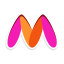

In [51]:
print(soup.prettify())

In [52]:
items= soup.find_all('li',class_='product-base')
print(len(items))

0


In [53]:
print("product-base" in tops.text)

False


ok so as beautiful soup can only get html and here we are getting dynamic htmp page after js for myntra so we will switch to selenium 

In [7]:
!pip install selenium

In [54]:
from selenium import webdriver
from bs4 import BeautifulSoup
import time
driver= webdriver.Chrome()

url = "https://www.myntra.com/women-shirts-tops-tees?f=Categories%3ATops"
driver.get(url)

time.sleep(20)
html = driver.page_source
soup = BeautifulSoup(html, "html.parser")

items= soup.find_all('li',class_='product-base')
print(len(items))

50


In [55]:
print(items[0].prettify())

<li class="product-base" id="36731315">
 <div class="product-thumbShim">
 </div>
 <div class="product-ratingsContainer">
  <span>
   4.2
  </span>
  <span class="myntraweb-sprite product-starIcon index-productRatingsExcellentIcon sprites-productRatingsExcellentIcon">
  </span>
  <div class="product-ratingsCount">
   <div class="product-separator">
    |
   </div>
   <!-- react-text: 438 -->
   7k
   <!-- /react-text -->
  </div>
 </div>
 <a data-refreshpage="true" href="tops/burgstudio9/burgstudio9-sweetheart-neck-cotton-crop-regular-top/36731315/buy" style="display: block;" target="_blank">
  <div class="product-imageSliderContainer">
   <div class="product-sliderContainer" style="display: block;">
    <div style="background: rgb(229, 241, 255);">
     <div style="height: 280px; width: 100%;">
      <picture class="img-responsive" draggable="false" style="width: 100%; height: 100%; display: block;">
       <source srcset="
    https://assets.myntassets.com/f_webp,dpr_1.0,q_60,w_210,c_

In [56]:
title=[]
rating=[]
rating_count=[]
brand=[]
price=[]
image_urls=[]
size=[]

for i in items:

    t = i.find('h4', class_='product-product')
    title.append(t.text.strip() if t else None)

    r = i.find('div', class_='product-ratingsContainer')
    rating.append(r.text.strip() if r else None)

    rc = i.find('div', class_='product-ratingsCount')
    rating_count.append(rc.text.strip() if rc else None)

    b = i.find('h3', class_='product-brand')
    brand.append(b.text.strip() if b else None)

    s = i.find('h4', class_='product-sizes')
    size.append(s.text.strip() if s else None)

    p = i.find('div', class_='product-price')
    price.append(p.text.strip() if p else None)

    img = i.find("img")
    if img:
        image_urls.append(img.get("src"))
    else:
        image_urls.append(None)

In [57]:
print(title[:3])
print(price[:3])
print(image_urls[:3])

['Sweetheart Neck Cotton Top', 'Print Top', 'Women Cotton Tank Top']
['Rs. 399Rs. 998(60% OFF)', 'Rs. 433Rs. 1399(Rs. 966 OFF)', 'Rs. 629Rs. 1499(58% OFF)']
['https://assets.myntassets.com/dpr_2,q_60,w_210,c_limit,fl_progressive/assets/images/2025/NOVEMBER/22/QbijvVj1_43d8025aadae495ca5cae4f1a016d840.jpg', 'https://assets.myntassets.com/dpr_2,q_60,w_210,c_limit,fl_progressive/assets/images/2026/APRIL/5/5qczCcWD_ff17bbb5fd6f400e93825164bba805bd.jpg', 'https://assets.myntassets.com/dpr_2,q_60,w_210,c_limit,fl_progressive/assets/images/2025/MARCH/20/XgbQ8k2z_f308ed48227242f3835ac423d154af84.jpg']


In [58]:
d= {'title':title, 'brand':brand, 'rating':rating, 'price':price, 'size':size, 'rating_count': rating_count, 'image_url':image_urls}

In [59]:
df_tops=pd.DataFrame(d)

In [60]:
print(df_tops.head())

                         title        brand   rating  \
0   Sweetheart Neck Cotton Top  Burgstudio9   4.2|7k   
1                    Print Top   DressBerry  4.3|457   
2        Women Cotton Tank Top    Vero Moda  4.5|221   
3  Square Neck Fitted Crop Top   LULU & SKY     None   
4                    Print Top       Kissah     None   

                          price       size rating_count  \
0       Rs. 399Rs. 998(60% OFF)   Sizes: L          |7k   
1  Rs. 433Rs. 1399(Rs. 966 OFF)   Sizes: S         |457   
2      Rs. 629Rs. 1499(58% OFF)  Sizes: XS         |221   
3      Rs. 788Rs. 2443(68% OFF)   Sizes: S         None   
4      Rs. 665Rs. 2999(78% OFF)  Sizes: XS         None   

                                           image_url  
0  https://assets.myntassets.com/dpr_2,q_60,w_210...  
1  https://assets.myntassets.com/dpr_2,q_60,w_210...  
2  https://assets.myntassets.com/dpr_2,q_60,w_210...  
3  https://assets.myntassets.com/dpr_2,q_60,w_210...  
4  https://assets.myntassets.com/

In [61]:
print(df_tops.shape)

(50, 7)


In [62]:
df_tops.head()

,title,brand,rating,price,size,rating_count,image_url
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2|7k,Rs. 399Rs. 998(60% OFF),Sizes: L,|7k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
1,Print Top,DressBerry,4.3|457,Rs. 433Rs. 1399(Rs. 966 OFF),Sizes: S,|457,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
2,Women Cotton Tank Top,Vero Moda,4.5|221,Rs. 629Rs. 1499(58% OFF),Sizes: XS,|221,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
3,Square Neck Fitted Crop Top,LULU & SKY,None,Rs. 788Rs. 2443(68% OFF),Sizes: S,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
4,Print Top,Kissah,None,Rs. 665Rs. 2999(78% OFF),Sizes: XS,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."


In [63]:
df_tops["rating_count"] = df_tops["rating_count"].str.split("|").str[1]

In [64]:
df_tops.head()

,title,brand,rating,price,size,rating_count,image_url
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2|7k,Rs. 399Rs. 998(60% OFF),Sizes: L,7k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
1,Print Top,DressBerry,4.3|457,Rs. 433Rs. 1399(Rs. 966 OFF),Sizes: S,457,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
2,Women Cotton Tank Top,Vero Moda,4.5|221,Rs. 629Rs. 1499(58% OFF),Sizes: XS,221,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
3,Square Neck Fitted Crop Top,LULU & SKY,None,Rs. 788Rs. 2443(68% OFF),Sizes: S,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
4,Print Top,Kissah,None,Rs. 665Rs. 2999(78% OFF),Sizes: XS,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."


In [65]:
df_tops["rating"] = df_tops["rating"].str.split("|").str[0]

In [66]:
df_tops.head()

,title,brand,rating,price,size,rating_count,image_url
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,Rs. 399Rs. 998(60% OFF),Sizes: L,7k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
1,Print Top,DressBerry,4.3,Rs. 433Rs. 1399(Rs. 966 OFF),Sizes: S,457,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
2,Women Cotton Tank Top,Vero Moda,4.5,Rs. 629Rs. 1499(58% OFF),Sizes: XS,221,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
3,Square Neck Fitted Crop Top,LULU & SKY,None,Rs. 788Rs. 2443(68% OFF),Sizes: S,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
4,Print Top,Kissah,None,Rs. 665Rs. 2999(78% OFF),Sizes: XS,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."


In [67]:
df_tops["size"] = df_tops["size"].str.split(":").str[1]

In [68]:
df_tops.head()

,title,brand,rating,price,size,rating_count,image_url
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,Rs. 399Rs. 998(60% OFF),L,7k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
1,Print Top,DressBerry,4.3,Rs. 433Rs. 1399(Rs. 966 OFF),S,457,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
2,Women Cotton Tank Top,Vero Moda,4.5,Rs. 629Rs. 1499(58% OFF),XS,221,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
3,Square Neck Fitted Crop Top,LULU & SKY,None,Rs. 788Rs. 2443(68% OFF),S,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
4,Print Top,Kissah,None,Rs. 665Rs. 2999(78% OFF),XS,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."


In [69]:
df_tops.sample(5)

,title,brand,rating,price,size,rating_count,image_url
37,Lace Neck Top,Moda Rapido,3.9,Rs. 299Rs. 2499(Rs. 2200 OFF),L,293,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
32,Cap-sleeved top,H&M,4.6,Rs. 629Rs. 699(10% OFF),M,438,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
13,Printed Halter Neck Top,R.Code by The Roadster Life Co.,None,Rs. 376Rs. 1299(Rs. 923 OFF),S,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
43,Women Cowl Neck Top,clobug,4.3,Rs. 427Rs. 2288(81% OFF),XS,10.3k,"https://assets.myntassets.com/dpr_2,q_60,w_210..."
10,Top Solid,CHARMGAL,None,Rs. 751Rs. 2199(66% OFF),S,None,"https://assets.myntassets.com/dpr_2,q_60,w_210..."


In [70]:
df_tops["current_price"] = (
    df_tops["price"]
    .astype(str)
    .str.extract(r'Rs\.\s*(\d+)')
)

In [71]:
df_tops["original_price"] = (
    df_tops["price"]
    .astype(str)
    .str.extract(r'Rs\.\s*\d+Rs\.\s*(\d+)')
)

In [72]:
df_tops["discount"] = (
    df_tops["price"]
    .astype(str)
    .str.extract(r'\((.*?)\)')
)

In [73]:
df_tops.head()

,title,brand,rating,price,size,rating_count,image_url,current_price,original_price,discount
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,Rs. 399Rs. 998(60% OFF),L,7k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399,998,60% OFF
1,Print Top,DressBerry,4.3,Rs. 433Rs. 1399(Rs. 966 OFF),S,457,"https://assets.myntassets.com/dpr_2,q_60,w_210...",433,1399,Rs. 966 OFF
2,Women Cotton Tank Top,Vero Moda,4.5,Rs. 629Rs. 1499(58% OFF),XS,221,"https://assets.myntassets.com/dpr_2,q_60,w_210...",629,1499,58% OFF
3,Square Neck Fitted Crop Top,LULU & SKY,None,Rs. 788Rs. 2443(68% OFF),S,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",788,2443,68% OFF
4,Print Top,Kissah,None,Rs. 665Rs. 2999(78% OFF),XS,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",665,2999,78% OFF


In [74]:
df_tops.drop(columns=["price"], inplace=True)

In [75]:
df_tops.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,7k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399,998,60% OFF
1,Print Top,DressBerry,4.3,S,457,"https://assets.myntassets.com/dpr_2,q_60,w_210...",433,1399,Rs. 966 OFF
2,Women Cotton Tank Top,Vero Moda,4.5,XS,221,"https://assets.myntassets.com/dpr_2,q_60,w_210...",629,1499,58% OFF
3,Square Neck Fitted Crop Top,LULU & SKY,None,S,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",788,2443,68% OFF
4,Print Top,Kissah,None,XS,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",665,2999,78% OFF


In [76]:
df_tops["category"]= 'tops'

In [77]:
df_tops.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,7k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399,998,60% OFF,tops
1,Print Top,DressBerry,4.3,S,457,"https://assets.myntassets.com/dpr_2,q_60,w_210...",433,1399,Rs. 966 OFF,tops
2,Women Cotton Tank Top,Vero Moda,4.5,XS,221,"https://assets.myntassets.com/dpr_2,q_60,w_210...",629,1499,58% OFF,tops
3,Square Neck Fitted Crop Top,LULU & SKY,None,S,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",788,2443,68% OFF,tops
4,Print Top,Kissah,None,XS,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",665,2999,78% OFF,tops


In [78]:
product_url = []
from urllib.parse import urljoin
for i in items:
    
    a = i.find("a")
    
    if a and a.get("href"):
        link = urljoin("https://www.myntra.com", a["href"])
    else:
        link = None

    product_url.append(link)

In [79]:
df_tops['product_url']= product_url

In [80]:
df_tops.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,7k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399,998,60% OFF,tops,https://www.myntra.com/tops/burgstudio9/burgst...
1,Print Top,DressBerry,4.3,S,457,"https://assets.myntassets.com/dpr_2,q_60,w_210...",433,1399,Rs. 966 OFF,tops,https://www.myntra.com/tops/dressberry/dressbe...
2,Women Cotton Tank Top,Vero Moda,4.5,XS,221,"https://assets.myntassets.com/dpr_2,q_60,w_210...",629,1499,58% OFF,tops,https://www.myntra.com/tops/vero+moda/vero-mod...
3,Square Neck Fitted Crop Top,LULU & SKY,None,S,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",788,2443,68% OFF,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...
4,Print Top,Kissah,None,XS,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",665,2999,78% OFF,tops,https://www.myntra.com/tops/kissah/kissah-prin...


In [81]:
df_tops['product_url']

0     https://www.myntra.com/tops/burgstudio9/burgst...
1     https://www.myntra.com/tops/dressberry/dressbe...
2     https://www.myntra.com/tops/vero+moda/vero-mod...
3     https://www.myntra.com/tops/lulu+%26+sky/lulu-...
4     https://www.myntra.com/tops/kissah/kissah-prin...
5     https://www.myntra.com/tops/h%26m/hm-lace-trim...
6     https://www.myntra.com/tops/aapre/aapre-cotton...
7     https://www.myntra.com/tops/kalamir/kalamir-pr...
8     https://www.myntra.com/tops/h%26m/hm-boat-neck...
9     https://www.myntra.com/tops/traquila/traquila-...
10    https://www.myntra.com/tops/charmgal/charmgal-...
11    https://www.myntra.com/tops/h%26m/hm-rib-knit-...
12    https://www.myntra.com/tops/burgstudio9/burgst...
13    https://www.myntra.com/tops/r.code+by+the+road...
14    https://www.myntra.com/tops/h%26m/hm-boat-neck...
15    https://www.myntra.com/tops/lulu+%26+sky/lulu-...
16    https://www.myntra.com/tops/mast+%26+harbour/m...
17    https://www.myntra.com/tops/h%26m/hm-ribbe

In [82]:
df_tops.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,7k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399,998,60% OFF,tops,https://www.myntra.com/tops/burgstudio9/burgst...
1,Print Top,DressBerry,4.3,S,457,"https://assets.myntassets.com/dpr_2,q_60,w_210...",433,1399,Rs. 966 OFF,tops,https://www.myntra.com/tops/dressberry/dressbe...
2,Women Cotton Tank Top,Vero Moda,4.5,XS,221,"https://assets.myntassets.com/dpr_2,q_60,w_210...",629,1499,58% OFF,tops,https://www.myntra.com/tops/vero+moda/vero-mod...
3,Square Neck Fitted Crop Top,LULU & SKY,None,S,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",788,2443,68% OFF,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...
4,Print Top,Kissah,None,XS,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",665,2999,78% OFF,tops,https://www.myntra.com/tops/kissah/kissah-prin...


In [83]:
print(product_url[:3])

['https://www.myntra.com/tops/burgstudio9/burgstudio9-sweetheart-neck-cotton-crop-regular-top/36731315/buy', 'https://www.myntra.com/tops/dressberry/dressberry-print-sleeveless-top/41154578/buy', 'https://www.myntra.com/tops/vero+moda/vero-moda-women-cotton-tank-top/33276277/buy']


In [84]:
df_tops_copy= df_tops.copy()

In [85]:
df_tops.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,7k,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399,998,60% OFF,tops,https://www.myntra.com/tops/burgstudio9/burgst...
1,Print Top,DressBerry,4.3,S,457,"https://assets.myntassets.com/dpr_2,q_60,w_210...",433,1399,Rs. 966 OFF,tops,https://www.myntra.com/tops/dressberry/dressbe...
2,Women Cotton Tank Top,Vero Moda,4.5,XS,221,"https://assets.myntassets.com/dpr_2,q_60,w_210...",629,1499,58% OFF,tops,https://www.myntra.com/tops/vero+moda/vero-mod...
3,Square Neck Fitted Crop Top,LULU & SKY,None,S,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",788,2443,68% OFF,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...
4,Print Top,Kissah,None,XS,None,"https://assets.myntassets.com/dpr_2,q_60,w_210...",665,2999,78% OFF,tops,https://www.myntra.com/tops/kissah/kissah-prin...


def convert_count(x):
    if pd.isna(x):
        return None
    if "k" in x:
        return float(x.replace("k", "")) * 1000
    
    return int(x)

df_tops["rating_count"] = df_tops["rating_count"].apply(convert_count)

In [86]:
def convert_count(x):
    if pd.isna(x):
        return None
    if "k" in x:
        return float(x.replace("k", "")) * 1000
    
    return int(x)

df_tops["rating_count"] = df_tops["rating_count"].apply(convert_count)

In [87]:
df_tops.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,7000.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399,998,60% OFF,tops,https://www.myntra.com/tops/burgstudio9/burgst...
1,Print Top,DressBerry,4.3,S,457.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",433,1399,Rs. 966 OFF,tops,https://www.myntra.com/tops/dressberry/dressbe...
2,Women Cotton Tank Top,Vero Moda,4.5,XS,221.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",629,1499,58% OFF,tops,https://www.myntra.com/tops/vero+moda/vero-mod...
3,Square Neck Fitted Crop Top,LULU & SKY,None,S,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",788,2443,68% OFF,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...
4,Print Top,Kissah,None,XS,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",665,2999,78% OFF,tops,https://www.myntra.com/tops/kissah/kissah-prin...


In [50]:
df_tops_final= df_tops.copy()

In [51]:
df_tops_final

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,6900.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399,998,60% OFF,tops,https://www.myntra.com/tops/burgstudio9/burgst...
1,Square Neck Fitted Crop Top,LULU & SKY,None,XL,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",788,2443,68% OFF,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...
2,Cotton Regular Top,Levis,4.8,L,17.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",949,1899,50% OFF,tops,https://www.myntra.com/tops/levis/levis-womens...
3,Polka Dot Printed Top,LULU & SKY,None,S,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",626,1895,67% OFF,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...
4,Striped Applique Tank Top,DressBerry,None,S,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",298,999,70% OFF,tops,https://www.myntra.com/tops/dressberry/dressbe...
5,Lace Peplum Top,Tokyo Talkies,4.3,S,10900.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",494,1499,67% OFF,tops,https://www.myntra.com/tops/tokyo+talkies/toky...
6,Print Top,DressBerry,4.3,S,430.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",535,1399,62% OFF,tops,https://www.myntra.com/tops/dressberry/dressbe...
7,Print Top,KALAMIR,4.6,XS,2500.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",799,2283,65% OFF,tops,https://www.myntra.com/tops/kalamir/kalamir-pr...
8,Embroidered Top,Tokyo Talkies,4.1,S,13700.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",377,1049,64% OFF,tops,https://www.myntra.com/tops/tokyo+talkies/toky...
9,Striped Neck Puff Sleeve Top,Burgstudio9,4.2,XS,6900.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",394,998,61% OFF,tops,https://www.myntra.com/tops/burgstudio9/burgst...


In [52]:
df_tops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           50 non-null     object 
 1   brand           50 non-null     object 
 2   rating          31 non-null     object 
 3   size            50 non-null     object 
 4   rating_count    31 non-null     float64
 5   image_url       11 non-null     object 
 6   current_price   50 non-null     object 
 7   original_price  45 non-null     object 
 8   discount        45 non-null     object 
 9   category        50 non-null     object 
 10  product_url     50 non-null     object 
dtypes: float64(1), object(10)
memory usage: 4.4+ KB


In [53]:
df_tops.sample(10)

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
19,Red Ribbed Halter Crop Top,Zucchini,None,Onesize,NaN,None,553,1349,59% OFF,tops,https://www.myntra.com/tops/zucchini/zucchini-...
41,Pure Cotton Bralette Top,The Souled Store,4.5,XXS,2100.0,None,699,NaN,NaN,tops,https://www.myntra.com/tops/the+souled+store/t...
47,Checked Top,Suo,None,M,NaN,None,965,2299,58% OFF,tops,https://www.myntra.com/tops/suo/suo-checked-to...
14,Halter Neck Overlap Top,Tokyo Talkies,4.4,S,854.0,None,287,1149,75% OFF,tops,https://www.myntra.com/tops/tokyo+talkies/toky...
25,Flutter Sleeve Cotton Top,Stylecast X Kotty,4.4,M,5.0,None,194,1299,85% OFF,tops,https://www.myntra.com/tops/stylecast+x+kotty/...
29,Shoulder Straps Top,MANGO,None,L,NaN,None,968,1490,35% OFF,tops,https://www.myntra.com/tops/mango/mango-should...
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,6900.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399,998,60% OFF,tops,https://www.myntra.com/tops/burgstudio9/burgst...
35,Embroidered Shirt Style Top,Nayam By Lakshita,4.4,M,2800.0,None,839,2195,62% OFF,tops,https://www.myntra.com/tops/nayam+by+lakshita/...
33,Women Printed V-Neck Top,QUIERO,4.3,XS,7900.0,None,668,2155,69% OFF,tops,https://www.myntra.com/tops/quiero/quiero-wome...
11,Printed Strappy Top,Bershka,None,XS,NaN,None,850,NaN,NaN,tops,https://www.myntra.com/tops/bershka/bershka-pr...


In [88]:
df_tops.isnull().sum()

title              0
brand              0
rating            14
size               0
rating_count      14
image_url          0
current_price      0
original_price     1
discount           1
category           0
product_url        0
dtype: int64

In [55]:
df_tops.describe()

,rating_count
count,31.000000
mean,2657.774194
std,3620.002953
min,5.000000
25%,119.000000
50%,756.000000
75%,3800.000000
max,13700.000000


In [56]:
df_tops.duplicated().sum()

np.int64(0)

In [57]:
df_tops= df_tops_final

In [58]:
df_tops.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,6900.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399,998,60% OFF,tops,https://www.myntra.com/tops/burgstudio9/burgst...
1,Square Neck Fitted Crop Top,LULU & SKY,None,XL,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",788,2443,68% OFF,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...
2,Cotton Regular Top,Levis,4.8,L,17.0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",949,1899,50% OFF,tops,https://www.myntra.com/tops/levis/levis-womens...
3,Polka Dot Printed Top,LULU & SKY,None,S,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",626,1895,67% OFF,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...
4,Striped Applique Tank Top,DressBerry,None,S,NaN,"https://assets.myntassets.com/dpr_2,q_60,w_210...",298,999,70% OFF,tops,https://www.myntra.com/tops/dressberry/dressbe...


In [89]:
df_tops["rating"] = pd.to_numeric(df_tops["rating"], errors="coerce")
df_tops["current_price"] = pd.to_numeric(df_tops["current_price"], errors="coerce")
df_tops["original_price"] = pd.to_numeric(df_tops["original_price"], errors="coerce")

In [90]:
df_tops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           50 non-null     object 
 1   brand           50 non-null     object 
 2   rating          36 non-null     float64
 3   size            50 non-null     object 
 4   rating_count    36 non-null     float64
 5   image_url       50 non-null     object 
 6   current_price   50 non-null     int64  
 7   original_price  49 non-null     float64
 8   discount        49 non-null     object 
 9   category        50 non-null     object 
 10  product_url     50 non-null     object 
dtypes: float64(3), int64(1), object(7)
memory usage: 4.4+ KB


In [91]:
df_tops["rating_count"] = df_tops["rating_count"].fillna(0).astype(int)

In [92]:
df_tops.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,7000,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399,998.0,60% OFF,tops,https://www.myntra.com/tops/burgstudio9/burgst...
1,Print Top,DressBerry,4.3,S,457,"https://assets.myntassets.com/dpr_2,q_60,w_210...",433,1399.0,Rs. 966 OFF,tops,https://www.myntra.com/tops/dressberry/dressbe...
2,Women Cotton Tank Top,Vero Moda,4.5,XS,221,"https://assets.myntassets.com/dpr_2,q_60,w_210...",629,1499.0,58% OFF,tops,https://www.myntra.com/tops/vero+moda/vero-mod...
3,Square Neck Fitted Crop Top,LULU & SKY,NaN,S,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",788,2443.0,68% OFF,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...
4,Print Top,Kissah,NaN,XS,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",665,2999.0,78% OFF,tops,https://www.myntra.com/tops/kissah/kissah-prin...


In [63]:
df_tops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           50 non-null     object 
 1   brand           50 non-null     object 
 2   rating          31 non-null     float64
 3   size            50 non-null     object 
 4   rating_count    50 non-null     int64  
 5   image_url       11 non-null     object 
 6   current_price   50 non-null     int64  
 7   original_price  45 non-null     float64
 8   discount        45 non-null     object 
 9   category        50 non-null     object 
 10  product_url     50 non-null     object 
dtypes: float64(2), int64(2), object(7)
memory usage: 4.4+ KB


In [93]:
df_tops["original_price"] = (
    df_tops["original_price"]
    .fillna(0)
    .astype(int)
)

In [94]:
df_tops.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,7000,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399,998,60% OFF,tops,https://www.myntra.com/tops/burgstudio9/burgst...
1,Print Top,DressBerry,4.3,S,457,"https://assets.myntassets.com/dpr_2,q_60,w_210...",433,1399,Rs. 966 OFF,tops,https://www.myntra.com/tops/dressberry/dressbe...
2,Women Cotton Tank Top,Vero Moda,4.5,XS,221,"https://assets.myntassets.com/dpr_2,q_60,w_210...",629,1499,58% OFF,tops,https://www.myntra.com/tops/vero+moda/vero-mod...
3,Square Neck Fitted Crop Top,LULU & SKY,NaN,S,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",788,2443,68% OFF,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...
4,Print Top,Kissah,NaN,XS,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",665,2999,78% OFF,tops,https://www.myntra.com/tops/kissah/kissah-prin...


In [66]:
df_tops_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           50 non-null     object 
 1   brand           50 non-null     object 
 2   rating          31 non-null     float64
 3   size            50 non-null     object 
 4   rating_count    50 non-null     int64  
 5   image_url       11 non-null     object 
 6   current_price   50 non-null     int64  
 7   original_price  50 non-null     int64  
 8   discount        45 non-null     object 
 9   category        50 non-null     object 
 10  product_url     50 non-null     object 
dtypes: float64(1), int64(3), object(7)
memory usage: 4.4+ KB


In [67]:
df_tops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           50 non-null     object 
 1   brand           50 non-null     object 
 2   rating          31 non-null     float64
 3   size            50 non-null     object 
 4   rating_count    50 non-null     int64  
 5   image_url       11 non-null     object 
 6   current_price   50 non-null     int64  
 7   original_price  50 non-null     int64  
 8   discount        45 non-null     object 
 9   category        50 non-null     object 
 10  product_url     50 non-null     object 
dtypes: float64(1), int64(3), object(7)
memory usage: 4.4+ KB


In [68]:
df_tops_final= df_tops.copy()

In [95]:
df_tops["discount"] = (
    df_tops["discount"]
    .str.extract(r"(\d+)")
)
df_tops["discount"] = pd.to_numeric(df_tops["discount"], errors="coerce").fillna(0)
df_tops["selling_price"] = (
    df_tops["original_price"] * (1 - df_tops["discount"] / 100)
)

In [96]:
df_tops.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url,selling_price
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,7000,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399,998,60.0,tops,https://www.myntra.com/tops/burgstudio9/burgst...,399.20
1,Print Top,DressBerry,4.3,S,457,"https://assets.myntassets.com/dpr_2,q_60,w_210...",433,1399,966.0,tops,https://www.myntra.com/tops/dressberry/dressbe...,-12115.34
2,Women Cotton Tank Top,Vero Moda,4.5,XS,221,"https://assets.myntassets.com/dpr_2,q_60,w_210...",629,1499,58.0,tops,https://www.myntra.com/tops/vero+moda/vero-mod...,629.58
3,Square Neck Fitted Crop Top,LULU & SKY,NaN,S,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",788,2443,68.0,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...,781.76
4,Print Top,Kissah,NaN,XS,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",665,2999,78.0,tops,https://www.myntra.com/tops/kissah/kissah-prin...,659.78


In [71]:
df_tops['current_price']= df_tops['selling_price']

In [72]:
df_tops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           50 non-null     object 
 1   brand           50 non-null     object 
 2   rating          31 non-null     float64
 3   size            50 non-null     object 
 4   rating_count    50 non-null     int64  
 5   image_url       11 non-null     object 
 6   current_price   50 non-null     float64
 7   original_price  50 non-null     int64  
 8   discount        50 non-null     float64
 9   category        50 non-null     object 
 10  product_url     50 non-null     object 
 11  selling_price   50 non-null     float64
dtypes: float64(4), int64(2), object(6)
memory usage: 4.8+ KB


In [97]:
df_tops= df_tops.drop('selling_price',axis=1)

In [98]:
df_tops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           50 non-null     object 
 1   brand           50 non-null     object 
 2   rating          36 non-null     float64
 3   size            50 non-null     object 
 4   rating_count    50 non-null     int64  
 5   image_url       50 non-null     object 
 6   current_price   50 non-null     int64  
 7   original_price  50 non-null     int64  
 8   discount        50 non-null     float64
 9   category        50 non-null     object 
 10  product_url     50 non-null     object 
dtypes: float64(2), int64(3), object(6)
memory usage: 4.4+ KB


In [99]:
df_tops['original_price']= df_tops['original_price'].astype(float)

In [76]:
df_tops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           50 non-null     object 
 1   brand           50 non-null     object 
 2   rating          31 non-null     float64
 3   size            50 non-null     object 
 4   rating_count    50 non-null     int64  
 5   image_url       11 non-null     object 
 6   current_price   50 non-null     float64
 7   original_price  50 non-null     float64
 8   discount        50 non-null     float64
 9   category        50 non-null     object 
 10  product_url     50 non-null     object 
dtypes: float64(4), int64(1), object(6)
memory usage: 4.4+ KB


In [77]:
df_tops.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,6900,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399.20,998.0,60.0,tops,https://www.myntra.com/tops/burgstudio9/burgst...
1,Square Neck Fitted Crop Top,LULU & SKY,NaN,XL,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",781.76,2443.0,68.0,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...
2,Cotton Regular Top,Levis,4.8,L,17,"https://assets.myntassets.com/dpr_2,q_60,w_210...",949.50,1899.0,50.0,tops,https://www.myntra.com/tops/levis/levis-womens...
3,Polka Dot Printed Top,LULU & SKY,NaN,S,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",625.35,1895.0,67.0,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...
4,Striped Applique Tank Top,DressBerry,NaN,S,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",299.70,999.0,70.0,tops,https://www.myntra.com/tops/dressberry/dressbe...


In [78]:
df_tops.isnull().sum()

title              0
brand              0
rating            19
size               0
rating_count       0
image_url         39
current_price      0
original_price     0
discount           0
category           0
product_url        0
dtype: int64

In [79]:
df_tops

,title,brand,rating,size,rating_count,image_url,current_price,original_price,discount,category,product_url
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,6900,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399.20,998.0,60.0,tops,https://www.myntra.com/tops/burgstudio9/burgst...
1,Square Neck Fitted Crop Top,LULU & SKY,NaN,XL,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",781.76,2443.0,68.0,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...
2,Cotton Regular Top,Levis,4.8,L,17,"https://assets.myntassets.com/dpr_2,q_60,w_210...",949.50,1899.0,50.0,tops,https://www.myntra.com/tops/levis/levis-womens...
3,Polka Dot Printed Top,LULU & SKY,NaN,S,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",625.35,1895.0,67.0,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...
4,Striped Applique Tank Top,DressBerry,NaN,S,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",299.70,999.0,70.0,tops,https://www.myntra.com/tops/dressberry/dressbe...
5,Lace Peplum Top,Tokyo Talkies,4.3,S,10900,"https://assets.myntassets.com/dpr_2,q_60,w_210...",494.67,1499.0,67.0,tops,https://www.myntra.com/tops/tokyo+talkies/toky...
6,Print Top,DressBerry,4.3,S,430,"https://assets.myntassets.com/dpr_2,q_60,w_210...",531.62,1399.0,62.0,tops,https://www.myntra.com/tops/dressberry/dressbe...
7,Print Top,KALAMIR,4.6,XS,2500,"https://assets.myntassets.com/dpr_2,q_60,w_210...",799.05,2283.0,65.0,tops,https://www.myntra.com/tops/kalamir/kalamir-pr...
8,Embroidered Top,Tokyo Talkies,4.1,S,13700,"https://assets.myntassets.com/dpr_2,q_60,w_210...",377.64,1049.0,64.0,tops,https://www.myntra.com/tops/tokyo+talkies/toky...
9,Striped Neck Puff Sleeve Top,Burgstudio9,4.2,XS,6900,"https://assets.myntassets.com/dpr_2,q_60,w_210...",389.22,998.0,61.0,tops,https://www.myntra.com/tops/burgstudio9/burgst...


In [80]:
!pip install ydata_profiling
from ydata_profiling import ProfileReport
prof= ProfileReport (df_tops)
prof.to_file(output_file= 'output.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 11/11 [00:00<00:00, 83.67it/s][A


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [81]:
df_tops.to_csv("looped_tops_data.csv", index=False)

In [100]:
df_tops["discount_percent"] = (
    (
        df_tops["original_price"] -
        df_tops["current_price"]
    )
    / df_tops["original_price"]
) * 100

In [101]:
df_tops["discount_percent"] = (
    df_tops["discount_percent"]
    .round(2)
)

In [103]:
df_tops = df_tops.drop("discount", axis=1)

In [104]:
df_tops.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,category,product_url,discount_percent
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,7000,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399,998.0,tops,https://www.myntra.com/tops/burgstudio9/burgst...,60.02
1,Print Top,DressBerry,4.3,S,457,"https://assets.myntassets.com/dpr_2,q_60,w_210...",433,1399.0,tops,https://www.myntra.com/tops/dressberry/dressbe...,69.05
2,Women Cotton Tank Top,Vero Moda,4.5,XS,221,"https://assets.myntassets.com/dpr_2,q_60,w_210...",629,1499.0,tops,https://www.myntra.com/tops/vero+moda/vero-mod...,58.04
3,Square Neck Fitted Crop Top,LULU & SKY,NaN,S,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",788,2443.0,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...,67.74
4,Print Top,Kissah,NaN,XS,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",665,2999.0,tops,https://www.myntra.com/tops/kissah/kissah-prin...,77.83


In [106]:
df_tops['current_price']=df_tops['current_price'].astype(float)

In [107]:
df_tops.head()

,title,brand,rating,size,rating_count,image_url,current_price,original_price,category,product_url,discount_percent
0,Sweetheart Neck Cotton Top,Burgstudio9,4.2,L,7000,"https://assets.myntassets.com/dpr_2,q_60,w_210...",399.0,998.0,tops,https://www.myntra.com/tops/burgstudio9/burgst...,60.02
1,Print Top,DressBerry,4.3,S,457,"https://assets.myntassets.com/dpr_2,q_60,w_210...",433.0,1399.0,tops,https://www.myntra.com/tops/dressberry/dressbe...,69.05
2,Women Cotton Tank Top,Vero Moda,4.5,XS,221,"https://assets.myntassets.com/dpr_2,q_60,w_210...",629.0,1499.0,tops,https://www.myntra.com/tops/vero+moda/vero-mod...,58.04
3,Square Neck Fitted Crop Top,LULU & SKY,NaN,S,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",788.0,2443.0,tops,https://www.myntra.com/tops/lulu+%26+sky/lulu-...,67.74
4,Print Top,Kissah,NaN,XS,0,"https://assets.myntassets.com/dpr_2,q_60,w_210...",665.0,2999.0,tops,https://www.myntra.com/tops/kissah/kissah-prin...,77.83


In [109]:
df_tops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             50 non-null     object 
 1   brand             50 non-null     object 
 2   rating            36 non-null     float64
 3   size              50 non-null     object 
 4   rating_count      50 non-null     int64  
 5   image_url         50 non-null     object 
 6   current_price     50 non-null     float64
 7   original_price    50 non-null     float64
 8   category          50 non-null     object 
 9   product_url       50 non-null     object 
 10  discount_percent  50 non-null     float64
dtypes: float64(4), int64(1), object(6)
memory usage: 4.4+ KB


In [108]:
df_tops.to_csv("looped_tops_data.csv", index=False)